Supponiamo di effettuare un fit lineare dei nostri dati sperimentali e supponiamo anche che le misure siano distribuite gaussianamente attorno alla retta attesa.

Se il modello lineare descrive bene i dati, allora i residui $r_i = y_i - f(x_i)$ dovrebbero oscillare casualmente attorno a zero: alcuni positivi (punti sopra il fit) e altri negativi (punti sotto il fit), senza mostrare particolari strutture o trend.

Nel calcolo del $\chi^2 = \sum_i \frac{(y_i-f(x_i))^2}{\sigma_i^2}$ l’informazione sul segno dei residui viene però persa, poiché gli scarti vengono elevati al quadrato. Di conseguenza, un punto molto sopra la retta e uno molto sotto contribuiscono allo stesso modo al valore del $\chi^2$.

Per questo motivo può capitare di ottenere un valore di $\chi^2$ apparentemente buono anche in presenza di un fit poco convincente. Ad esempio, potrei osservare intere regioni con residui tutti positivi, alternate a regioni con residui tutti negativi.

Un comportamento del genere suggerisce la presenza di una struttura sistematica nei dati, come ad esempio una curvatura o una concavità, che il modello lineare non riesce a descrivere.

Per evidenziare queste situazioni si utilizzano test che tengono conto anche del segno dei residui, verificando se la loro alternanza sia realmente casuale oppure presenti sequenze troppo ordinate per essere compatibili con l’ipotesi nulla $H_0:\ \text{fit buono}$.

Quindi l'idea per il nuovo test che vogliamo effettuare passa per la costruzione di una nuova statistica di test che conti in maniera combinatoriale quante alternanze di segni ci sono nell'ipotesi in cui avere un residuo sopra fit sia equiprobabile ad averlo sotto. Alla fine costruisco la regionedi accettazione e rifiuto su questa nuova statistica. 

Definiamo a questo punto le variabili $n_+$ ed $n_-$ che rappresentano rispettivamente il conteggio di quanti punti stanno sopra e quanti punti stanno sotto e definisco la loro variabile somma:

$$
\boxed{n = n_+ + n_-}
$$

Chiamo invece $RUN$ una sequenza di deviazioni dal fit dello stesso segno. Quindi per esempio se tutti i punti stanno sopra il fit, e quindi $n_-=0$, allora $RUN=1$ perchè ho un'unica sequenza e la probabilità associata a quando $RUN=1$ sarà chiaramente $P(RUN=1)=1$. Ovviamente c'è il caso analogo in cui $n_+=0$

Se poi $n_+$ ed $n_-$ sono entrambi non nulli, allora individuerò un numero minimo di sequenze pari a 2 (tipo tot punti sopra e poi tutti sotto, oppure tot punti sotto e poi tutti sopra e quindi ho un minimo di 2 sequenze) fino al numero massimo che è proprio $n$ di sequenze e questo succede quando ne ho uno sopra, uno sotto, uno sopra, uno sotto ecc... $\Rightarrow RUN_{min}=2 $ ; $RUN_{max}n$






Dato che non mi interessa l'ordine con cui avvengono ma voglio solo sapere il numero di configuraioni possibili allora, una volta fissati i valori di $n_+$ ed $n_-$, posso calcolare tale grandezza come: $w_{TOT}=\binom{n}{n_+}=\frac{n!}{(n_+!)\cdot (n_-!)}$.

A questo punto posso determinare quante configurazioni producono una certa sequenza di alternanze tra segni positivi e negativi e calcolare la probabilità associata ad osservarla.

Il tutto quindi si riduce ad un problema di logica combinatoriale. 

Giusto per capirci facciamo un esempio numerico. Supponiamo di avere n=12 punti totali e mettiamoci nel caso in cui ne ho 6 sopra e 6 sotto, ovvero $n_+=6$ ed $n_-=6$. 

In [56]:
from IPython.display import display, Math
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

n_plus=6
n_minus=6
n=n_plus+n_minus
w_tot=math.comb(n,n_plus)

display(Math(r"\text{Il numero di configurazioni possibili è } w_{tot}="+f"{w_tot}"))


<IPython.core.display.Math object>

Voglio adesso contare quali sono le possibili configurazioni in cui ho 4 blocchi di segni partendo da una configurazione positiva. Ovvero le configurazioni in cui 

$$\text{[Gruppo di +]} \rightarrow \text{[Gruppo di -]} \rightarrow \text{[Gruppo di +]} \rightarrow \text{[Gruppo di -]}$$

Ovvero quelle configurazioni in cui ho 3 cambi di segno (3 alternanze).

Per farlo su python usiamo la funzione product della libreria itertools che mi genera tutte le possibili sequenze di segni positivi e negativi specificando che la ogni sequenza deve avere un massimo di 12 elementi

In [49]:
from itertools import product

sequenze = product(['+','-'],repeat=n)  #genera tutte le sequenze possibili di + e - che hanno 12 elementi senza imporre che n_+=6 ed n_=6

sequenze_accettate= []

for seq in sequenze:  #seq sono così delle liste
    if seq.count('+')!=6:  #scarto tutte le sequenze con n_+ diverso da 6, e quindi pure tutte quelle con n_- diverso da 6
        continue
    if seq[0]!='+':  # scarto tutte le liste che non cominciano con +
        continue
    

    else:
        alternanze=0
        for i in range(1,len(seq)):
            if seq[i-1]!=seq[i]:
                alternanze+=1
        if alternanze == 3:
            sequenze_accettate.append(seq)

dz={
    'sequenze accettate':sequenze_accettate
}

df = pd.DataFrame(dz)

display(df)

,sequenze accettate
0,"(+, +, +, +, +, -, +, -, -, -, -, -)"
1,"(+, +, +, +, +, -, -, +, -, -, -, -)"
2,"(+, +, +, +, +, -, -, -, +, -, -, -)"
3,"(+, +, +, +, +, -, -, -, -, +, -, -)"
4,"(+, +, +, +, +, -, -, -, -, -, +, -)"
5,"(+, +, +, +, -, +, +, -, -, -, -, -)"
6,"(+, +, +, +, -, -, +, +, -, -, -, -)"
7,"(+, +, +, +, -, -, -, +, +, -, -, -)"
8,"(+, +, +, +, -, -, -, -, +, +, -, -)"
9,"(+, +, +, +, -, -, -, -, -, +, +, -)"


Quindi vengono solamente 25.



Riusciamo poi alla fine ad ottenre la probabilità del numero di blocchi o run quando il numero di alternanze è pari oppure quando il numero di alternanze e dispari e quindi in questo modo si riesce a costuire la pdf, e poi direttamente su questa facciamo il test statistico.

In particolare si fa vedere che la pdf nel caso di numero di run pari, ovvero $r=2k$, si costruisce come 

$$\boxed{P(R=2k)=
\frac{
2\binom{n_+-1}{k-1}\binom{n_--1}{k-1}
}{
\binom{n}{n_+}
}}$$

Ovvero 2 volte per il numero di configurazioni dei '+' per il numero di configurazioni dei '-' diviso il numero di configurazioni totali.

Quando sono dispari invece ci sono due contributi perchè il blocco dispari aggiuntivo può essere aggiunto sia all'inizio della sequenza che alla fine. Infatti si ha che:

$$\boxed{P(R=2k+1)=
\frac{
\binom{n_+-1}{k}\binom{n_--1}{k-1}
+
\binom{n_+-1}{k-1}\binom{n_--1}{k}
}{
\binom{n}{n_+}
}}$$

Implementiamo la pdf!


In [70]:
def P_run(r, n_plus, n_minus):

    n = n_plus + n_minus

    # RUN PARI
    if r % 2 == 0:

        k = r // 2

        num = (
            2 *
            math.comb(n_plus - 1, k - 1) *
            math.comb(n_minus - 1, k - 1)
        )

    # RUN DISPARI
    else:

        k = (r - 1) // 2

        num = (
            math.comb(n_plus - 1, k) *
            math.comb(n_minus - 1, k - 1)
            +
            math.comb(n_plus - 1, k - 1) *
            math.comb(n_minus - 1, k)
        )

    den = math.comb(n, n_plus)

    return num / den

In [71]:
RUNs = np.arange(2, n + 1)  #i RUN vanno da un minimo di 2 ad un massimo di n

frequenze = []

for r in RUNs:

    try:
        frequenze.append(P_run(r, n_plus, n_minus))

    except ValueError:

        frequenze.append(0)

frequenze = np.array(frequenze)

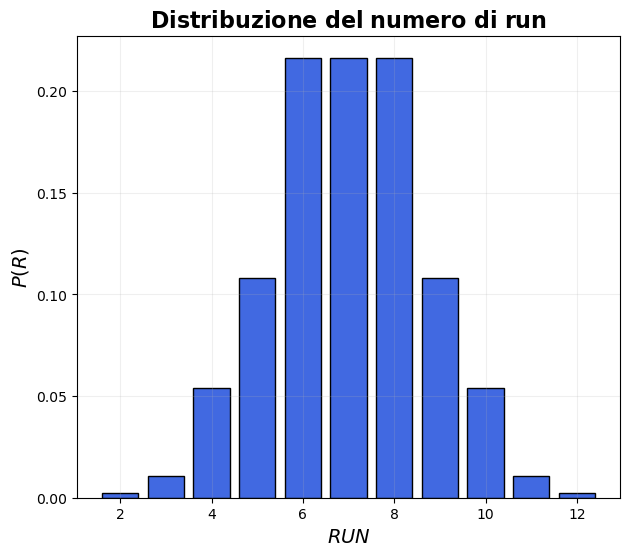

In [ ]:
fig, ax = plt.subplots(figsize=(7,6))

ax.bar(
    RUNs,
    frequenze,
    width=0.8,
    edgecolor='black',
    color= 'royalblue'
)

ax.set_title(
    r'$\mathbf{Distribuzione\ del\ numero\ di\ run}$',
    fontsize=16
)

ax.set_xlabel(
    r'$\mathit{RUN}$',
    fontsize=14
)

ax.set_ylabel(
    r'$\mathit{P(R)}$',
    fontsize=14
)

ax.grid(True,alpha=0.2)

plt.show()

Quindi posso trovare la regione di accettazione e rifiuto su questa pdf facendone la cumulativa. Il test viene fatto sul numero di run ed è un test ad una coda. Se il numero di run viene troppo piccolo di una certa soglia $r_\alpha$ che fisso per soddisfare la significiatività $\alpha$ richiesta dal test, allora scarto $H_0$, altrimenti posso accettare l'ipotesi che il mio fit sia buono.

Per implementare questa cosa su python mi serve conoscere la cumulativa della pdf che ho chiamato e definito più su nel codice come $P_{run}(r, n_plu, n_minus)$. Per farlo usiamo la funzione di numpy 'np.cumsum()'. Questa serve perchè fa proprio la cumulativa di una pdf discreta quando l'applichiamo ai valori ottenuti da tale distribuzione.

In [77]:
alpha=0.05 #per test al 95%

cdf = np.cumsum(frequenze)

# come abbiamo già visto per fare la soglia del test ad una coda su una pdf discreta bisogna ciclare sui valori possibili
for r, F in zip(RUNs, cdf):
    if F >= alpha:
        r_alpha = r
        break

display(Math(r"\text{La soglia determinata è } r_{\alpha}="+f"{r_alpha}"))


<IPython.core.display.Math object>

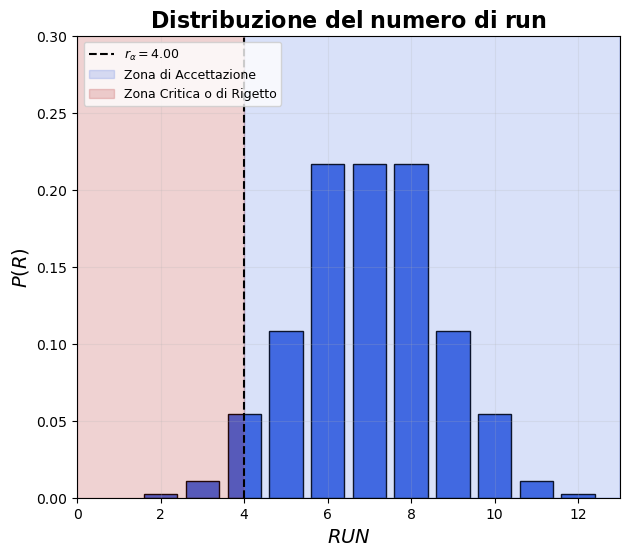

In [92]:
x_cut= r_alpha
fig,ax = plt.subplots(figsize=(7,6))
ax.bar(
    RUNs,
    frequenze,
    width=0.8,
    edgecolor='black',
    color= 'royalblue'
)

ax.set_title(
    r'$\mathbf{Distribuzione\ del\ numero\ di\ run}$',
    fontsize=16
)

ax.set_xlabel(
    r'$\mathit{RUN}$',
    fontsize=14
)

ax.set_ylabel(
    r'$\mathit{P(R)}$',
    fontsize=14
)
ax.axvline(x_cut,linestyle='--',label=r'$\mathit{r_{\alpha}=}$' + f'{x_cut:.2f}',color='black')

xs = np.linspace(0,13,1000)

mask = (xs>x_cut)
ax.fill_between(xs[mask],
                1,
                color='royalblue',
                alpha=0.2,
                label='Zona di Accettazione ',
                )

mask = (xs<x_cut)
ax.fill_between(xs[mask],
                1,
                color='firebrick',
                alpha=0.2,
                label='Zona Critica o di Rigetto',
                )
ax.set_ylim(0,0.30)
ax.set_xlim(0,13)
plt.legend(loc='upper left',
           fontsize=9)
plt.grid(True,alpha=0.2)

Quindi in conclusione per un fit a 12 punti di cui 6 punti sono sopra e 6 punti sono sotto, la regione di accettazione è per un numero di run maggiore di 4. Se mi esce un numero di run compreso tra 1 e 4 (con 4 incluso) concludo che il mio non è un buon fit, in quanto questo fi lineare non riesce a seguire bene eventuali concavità e convessità che si vengono a creare in presenza di "trend" che seguono i miei punti sperimentali. 